<a href="https://colab.research.google.com/github/shireesha-palakurla/Plant_Disease_Detection/blob/main/Plant_Disease_Detection_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Extract Dataset from ZIP File**

In [11]:
import zipfile

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('Dataset Extracted Successfully')

Dataset Extracted Successfully


**Install Libraries**

In [12]:
pip install tensorflow opencv-python matplotlib

**Import Libraries**

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Set Dataset Path**

In [14]:
dataset_path = "/content/dataset/PlantVillage"

print(os.listdir(dataset_path))

['Tomato_Spider_mites_Two_spotted_spider_mite', 'Potato___healthy', 'Tomato_healthy', 'Tomato_Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


**Create Image Generator**

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

**Training Generator**

In [16]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 16516 images belonging to 15 classes.


**Validation Generator**

In [17]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4122 images belonging to 15 classes.


**Build CNN Model**

In [18]:
model = Sequential()

# Layer 1
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3) # Corrected input_shape
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    train_generator.num_classes,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile Model**

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [21]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20
)

Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 584s 1s/step - accuracy: 0.4754 - loss: 1.6131 - val_accuracy: 0.7227 - val_loss: 0.8501
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.7096 - loss: 0.8811 - val_accuracy: 0.8108 - val_loss: 0.5432
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 570s 1s/step - accuracy: 0.7722 - loss: 0.6762 - val_accuracy: 0.8406 - val_loss: 0.4757
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.8106 - loss: 0.5550 - val_accuracy: 0.8595 - val_loss: 0.3989
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.8369 - loss: 0.4801 - val_accuracy: 0.8840 - val_loss: 0.3426
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 569s 1s/step - accuracy: 0.8607 - loss: 0.3991 - val_accuracy: 0.8891 - val_loss: 0.3197
Epoch 7/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.8797 - loss: 0.3392 - val_accuracy: 0.8918 - val_loss: 0.3363
Epoch 8/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 561s 1s/step - accuracy: 0.8923 - loss: 0.3169 - val_accu

**Save Model**

In [22]:
model.save_weights(
    "plant_weights.weights.h5"
)

print('Model Saved Successfully')

Model Saved Successfully


**Accuracy Graph**

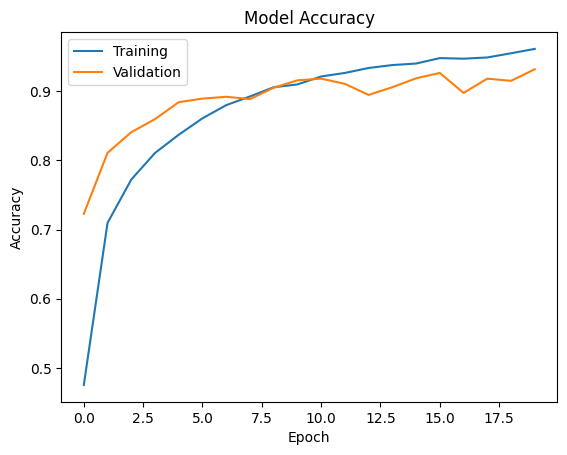

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training','Validation'])

plt.show()

**Loss Graph**

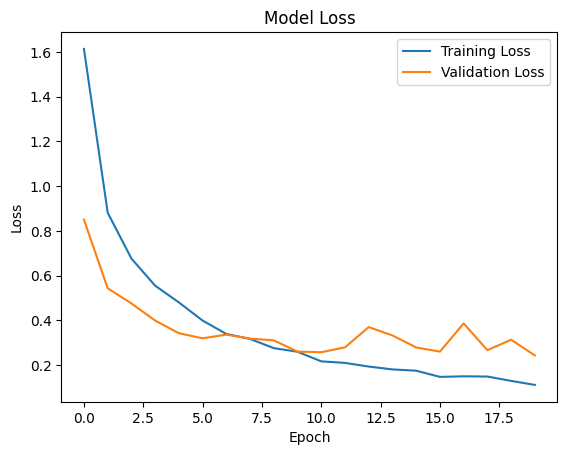

In [24]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

**Upload Test Image**

In [25]:
from google.colab import files

uploaded = files.upload()

Saving tomato-yellow.JPG to tomato-yellow.JPG


**Preprocess Image**

In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255

**Predict Disease**

In [27]:
prediction = model.predict(img_array)

class_indices = train_generator.class_indices

classes = list(class_indices.keys())

result = classes[np.argmax(prediction)]

print("Predicted Disease:")
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Predicted Disease:
Tomato__Tomato_YellowLeaf__Curl_Virus


**Display Result**

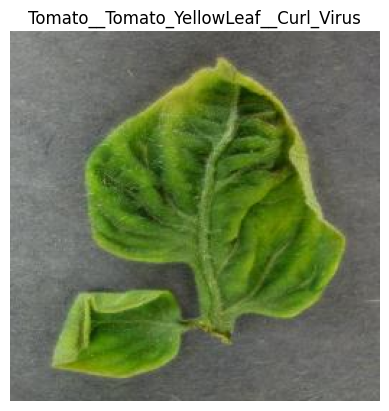

In [28]:
plt.imshow(image.load_img(img_path))
plt.title(result)
plt.axis('off')
plt.show()

**Install Seaborn**

In [29]:
!pip install seaborn

**Import Metrics Libraries**

In [30]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

**Generate Predictions**

In [31]:
Y_pred = model.predict(validation_generator)

y_pred = np.argmax(Y_pred, axis=1)

y_true = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 358ms/step


**Classification Report**

In [32]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.06      0.06      0.06       199
                     Pepper__bell___healthy       0.06      0.06      0.06       295
                      Potato___Early_blight       0.05      0.04      0.05       200
                       Potato___Late_blight       0.03      0.03      0.03       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.11      0.12      0.11       425
                        Tomato_Early_blight       0.04      0.04      0.04       200
                         Tomato_Late_blight       0.09      0.08      0.09       381
                           Tomato_Leaf_Mold       0.04      0.04      0.04       190
                  Tomato_Septoria_leaf_spot       0.10      0.10      0.10       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.06      0.06

**Confusion Matrix Graph**

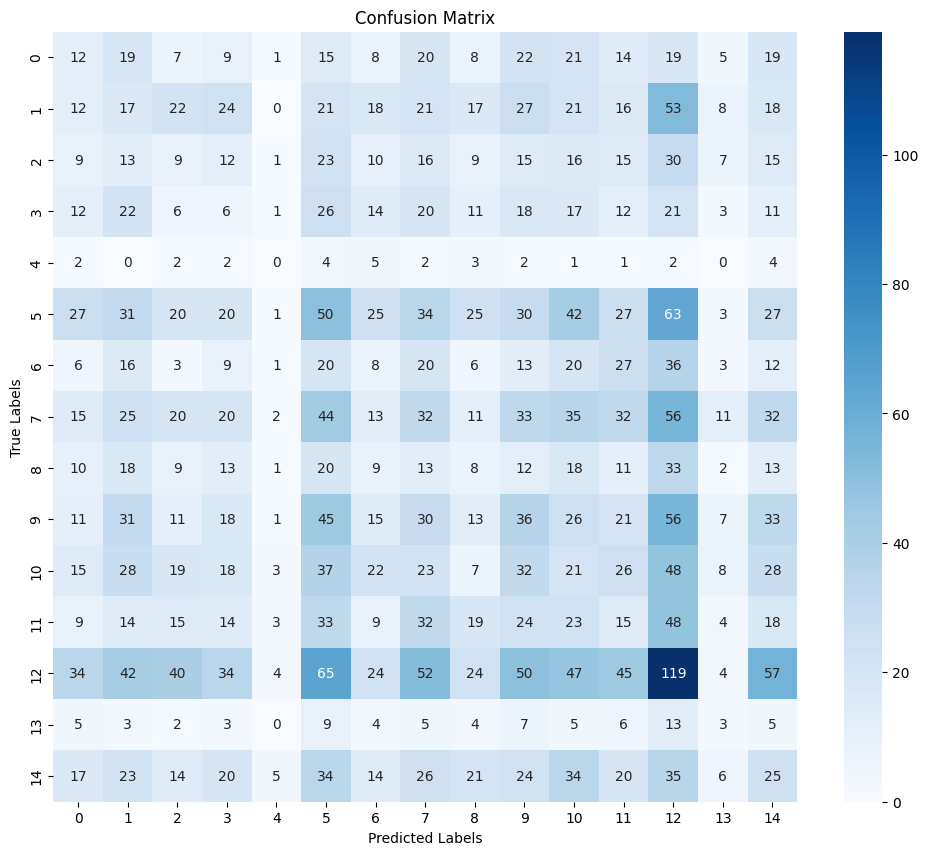

In [33]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.show()

**Overall Accuracy**

In [34]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy:")
print(accuracy * 100)

129/129 ━━━━━━━━━━━━━━━━━━━━ 40s 310ms/step - accuracy: 0.9316 - loss: 0.2434
Validation Accuracy:
93.15866231918335
